# Full TF-nnPU vs adapted CMPA comparison — same prefix-level split

This notebook keeps the **TF-nnPU branch and comparison protocol from the uploaded
`FULL_TF_nnPU_vs_GAT_PREFIX_LEVEL_SPLIT(2).ipynb`** and replaces the GAT-LSTM
baseline with an adapted implementation of:

**S. Lee, B. Song, and J. Shin, "Collision Prediction in an Integrated Framework
of Scenario-Based and Data-Driven Approaches," IEEE Access, vol. 12,
pp. 55234–55247, 2024, DOI: 10.1109/ACCESS.2024.3388099.**

The comparison contains:

1. **TF-nnPU** — unchanged from the supplied notebook.
2. **CMPA-BCE** — binary adaptation of Lee *et al.* using standard BCE.
3. **CMPA-nnPU** — the exact same adapted CMPA network/input, but trained with
   the same nnPU loss used by TF-nnPU.

This directly tests whether the nnPU supervision advantage transfers to an
independently proposed IEEE collision-prediction framework.

> **Important protocol note.** This notebook intentionally preserves the
> prefix-level random split from the supplied comparison notebook so the new
> CMPA results are directly comparable to those runs. The paper manuscript,
> however, currently states scenario-level splitting. Before using the results
> in the final reviewer response, the same comparison should also be run under
> the manuscript's final split protocol if that claim is retained.


In [9]:
# ============================================================
# 1. Imports / configuration
# ============================================================

import os
import math
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

import matplotlib.pyplot as plt

try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Same endpoint set for every model:
# frame_id 3 = 4 observed frames; frame_id 14 = 15 observed frames
MIN_ENDPOINT = 3
MAX_ENDPOINT = 14

N_OUTER_FOLDS = 5
INNER_VAL_FRACTION = 0.15

# Exact Stage-1 hyperparameters from your uploaded notebook
AE_EPOCHS = 20
AE_BATCH_SIZE = 16
AE_LR = 1e-3
AE_WEIGHT_DECAY = 1e-4

# Exact Stage-2 hyperparameters from your uploaded notebook
CLF_EPOCHS = 200
CLF_BATCH_SIZE = 32
CLF_LR = 1e-4
CLF_WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 8
EARLY_STOP_MIN_DELTA = 1e-3

POS_PRIOR = 0.10

NOISE_CONDITIONS = [
    ("none", 0.00),
    ("symmetric", 0.05),
    ("symmetric", 0.10),
    ("symmetric", 0.15),
    ("symmetric", 0.20),
    ("p_to_u", 0.05),
    ("p_to_u", 0.10),
    ("p_to_u", 0.15),
    ("p_to_u", 0.20),
]

Using device: cuda


## Exact data-loading functions from your model notebook

In [10]:
def load_mix_txt(path: str) -> np.ndarray:
    """Load TXT file with columns:
    0: time/frame index
    1: distance
    2: angle
    3: sin(yaw)
    4: cos(yaw)
    5: speed
    6: frame-level label (0 = safe, 1 = collision)
    7: sequence_id
    """
    data = np.loadtxt(path)
    if data.ndim == 1:
        data = data[None, :]  # ensure 2D
    return data


def group_sequences_with_frame_labels(data: np.ndarray):
    """Group flat data by sequence_id and sort by time.

    Returns:
        sequences: list of arrays, each of shape (T_i, 5) with features
                   [distance, angle, sin(yaw), cos(yaw), speed]
        frame_labels: list of arrays, each of shape (T_i,) with 0/1 labels
        seq_ids: list of sequence ids
    """
    seq_col = data[:, 7].astype(int)
    time_col = data[:, 0]
    unique_ids = np.unique(seq_col)

    sequences = []
    frame_labels = []
    seq_ids = []

    for sid in unique_ids:
        mask = (seq_col == sid)
        seq_data = data[mask]
        # sort by time
        order = np.argsort(seq_data[:, 0])
        seq_data = seq_data[order]

        # features: columns 1..5
        X = seq_data[:, 1:6].astype(np.float32)
        y = seq_data[:, 6].astype(np.float32)

        sequences.append(X)
        frame_labels.append(y)
        seq_ids.append(int(sid))

    return sequences, frame_labels, seq_ids

## Exact padding utilities from your model notebook

In [11]:
def pad_collate_unsupervised(batch):
    """Collate function for UnsupervisedSeqDataset.

    Args:
        batch: list of tensors [T_i, F]

    Returns:
        padded: (B, T_max, F)
        pad_mask: (B, T_max) bool, True where padding
    """
    lengths = [x.shape[0] for x in batch]
    padded = pad_sequence(batch, batch_first=True)  # (B, T_max, F)
    T_max = padded.shape[1]

    # pad_mask: True where positions are padding
    idxs = torch.arange(T_max).unsqueeze(0).expand(len(lengths), -1)
    lengths_tensor = torch.tensor(lengths).unsqueeze(1)
    pad_mask = idxs >= lengths_tensor

    return padded, pad_mask


def pad_collate_supervised(batch):
    """Collate function for supervised prefix dataset.

    Args:
        batch: list of (tensor[T_i, F], label)

    Returns:
        padded: (B, T_max, F)
        labels: (B,)
        pad_mask: (B, T_max) bool
    """
    seqs, labels = zip(*batch)
    lengths = [x.shape[0] for x in seqs]
    padded = pad_sequence(seqs, batch_first=True)  # (B, T_max, F)
    T_max = padded.shape[1]

    idxs = torch.arange(T_max).unsqueeze(0).expand(len(lengths), -1)
    lengths_tensor = torch.tensor(lengths).unsqueeze(1)
    pad_mask = idxs >= lengths_tensor

    labels = torch.stack(labels)  # (B,)
    return padded, labels, pad_mask

## Exact `TemporalEncoder` from your model notebook

In [12]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for sequences with batch_first=True.

    Expects input of shape (B, T, D).
    """
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D)
        T = x.size(1)
        x = x + self.pe[:, :T, :]
        return x


class TemporalEncoder(nn.Module):
    """Shared temporal encoder: input_dim -> d_model via TransformerEncoder."""
    def __init__(
        self,
        input_dim: int = 5,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        max_len: int = 500,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model

        self.in_proj = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model, max_len=max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        """Forward pass.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool, True where padding

        Returns:
            h: (B, T, d_model)
        """
        h = self.in_proj(x)
        h = self.pos(h)
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        return h

## Exact `TemporalAutoencoder` from your model notebook

In [13]:
class TemporalAutoencoder(nn.Module):
    """Temporal autoencoder: encoder + linear decoder back to input_dim."""
    def __init__(self, encoder: TemporalEncoder):
        super().__init__()
        self.encoder = encoder
        self.out_proj = nn.Linear(encoder.d_model, encoder.input_dim)

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None) -> torch.Tensor:
        """Reconstruct the input sequence.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool

        Returns:
            x_hat: (B, T, input_dim)
        """
        h = self.encoder(x, pad_mask=pad_mask)
        x_hat = self.out_proj(h)
        return x_hat

## Exact `TemporalRiskTransformer` from your model notebook

In [14]:
class TemporalRiskTransformer(nn.Module):
    """Transformer encoder + masked attention pooling -> sequence-level logit.

    Uses a pretrained TemporalEncoder and a small MLP head.
    """
    def __init__(self, encoder: TemporalEncoder, d_hidden: int = 64, dropout: float = 0.1):
        super().__init__()
        self.encoder = encoder

        d_model = encoder.d_model

        # Attention pooling over time
        self.pool = nn.Linear(d_model, 1)

        # Classification head
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1),
        )

    def forward(self, x: torch.Tensor, pad_mask: torch.Tensor = None):
        """Forward pass.

        Args:
            x: (B, T, input_dim)
            pad_mask: (B, T) bool

        Returns:
            logits: (B,) raw logits for collision probability
            z_seq: (B, d_model) pooled sequence representation
        """
        h = self.encoder(x, pad_mask=pad_mask)  # (B, T, d_model)

        # Attention logits over time
        att_logits = self.pool(h).squeeze(-1)  # (B, T)

        if pad_mask is not None:
            att_logits = att_logits.masked_fill(pad_mask, float("-inf"))

        att_weights = F.softmax(att_logits, dim=1)  # (B, T)

        # Weighted sum
        z_seq = torch.sum(h * att_weights.unsqueeze(-1), dim=1)  # (B, d_model)

        logits = self.head(z_seq).squeeze(-1)  # (B,)
        return logits, z_seq

## Exact nnPU loss from your model notebook

In [15]:
# === nnPU (Positive–Unlabeled) loss for collision (positive) vs safe (unlabeled) ===
import torch.nn.functional as F

def nnpu_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    prior: float,
    gamma: float = 1.0,
    beta: float = 0.0,
) -> torch.Tensor:
    # nnPU loss (non-negative PU) with logistic loss.
    #
    # logits: (B,)
    # targets: (B,) in {0, 1}, where:
    #     1 = positive (collision)
    #     0 = unlabeled (safe / mixture)
    #
    # prior: π_p, estimated positive prior (collision prior) in the training set.
    # gamma, beta: hyperparameters controlling how aggressively to handle negative risk.

    # Ensure float
    y = targets.float()
    logits = logits.view(-1)

    # Masks
    pos_mask = (y == 1)
    unl_mask = (y == 0)

    # Logistic loss for y=+1 and y=-1
    # l(f, +1) = log(1 + exp(-f)) = softplus(-f)
    # l(f, -1) = log(1 + exp(f))  = softplus(f)
    def loss_pos(z):
        return F.softplus(-z)

    def loss_neg(z):
        return F.softplus(z)

    device = logits.device

    if pos_mask.any():
        pos_logits = logits[pos_mask]
        L_p_pos = loss_pos(pos_logits).mean()          # E_p[l(f, +1)]
        L_p_neg = loss_neg(pos_logits).mean()          # E_p[l(f, -1)]
    else:
        # No positive examples in this batch; set to zero
        L_p_pos = torch.tensor(0.0, device=device)
        L_p_neg = torch.tensor(0.0, device=device)

    if unl_mask.any():
        unl_logits = logits[unl_mask]
        L_u_neg = loss_neg(unl_logits).mean()          # E_u[l(f, -1)]
    else:
        L_u_neg = torch.tensor(0.0, device=device)

    # Positive risk
    risk_positive = prior * L_p_pos

    # Negative risk estimate
    risk_negative = L_u_neg - prior * L_p_neg

    # Non-negative PU trick
    if risk_negative.item() < -beta:
        # In this regime, flip the sign of the negative risk and scale by gamma
        loss = risk_positive - gamma * risk_negative
    else:
        loss = risk_positive + risk_negative

    return loss

def upu_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    prior: float,
    gamma: float = 1.0,
    beta: float = 0.0,
) -> torch.Tensor:
    """Unbiased PU (uPU) loss — same as nnPU but WITHOUT non-negative clipping."""

    y = targets.float()
    logits = logits.view(-1)

    pos_mask = (y == 1)
    unl_mask = (y == 0)

    def loss_pos(z):
        return F.softplus(-z)

    def loss_neg(z):
        return F.softplus(z)

    # Positive risk
    if pos_mask.sum() > 0:
        L_p_pos = loss_pos(logits[pos_mask]).mean()
        L_p_neg = loss_neg(logits[pos_mask]).mean()
    else:
        L_p_pos = torch.tensor(0.0, device=logits.device)
        L_p_neg = torch.tensor(0.0, device=logits.device)

    # Unlabeled risk
    if unl_mask.sum() > 0:
        L_u_neg = loss_neg(logits[unl_mask]).mean()
    else:
        L_u_neg = torch.tensor(0.0, device=logits.device)

    risk_positive = prior * L_p_pos
    risk_negative = L_u_neg - prior * L_p_neg  # <-- NO max(0, ...) here

    loss = risk_positive + risk_negative
    return loss

## Exact early-stopping class from your model notebook

In [16]:
import copy
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-4, mode="max"):
        """Simple early stopping with best-weight restore.
        mode="max": metric should increase (e.g., AUC)
        mode="min": metric should decrease (e.g., loss)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best = -np.inf if mode == "max" else np.inf
        self.num_bad_epochs = 0
        self.best_state = None

    def step(self, metric, model):
        improved = (metric > self.best + self.min_delta) if self.mode == "max" else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.num_bad_epochs = 0
            self.best_state = copy.deepcopy(model.state_dict())
            return False
        self.num_bad_epochs += 1
        return self.num_bad_epochs >= self.patience

    def restore_best_weights(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

## Verify that the TF model is still exactly 71,746 trainable parameters

In [17]:
# ============================================================
# 9. Verify the copied TF-nnPU architecture
# ============================================================

_exact_encoder = TemporalEncoder(
    input_dim=5,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=128,
    dropout=0.1,
    max_len=500,
)
_exact_tf = TemporalRiskTransformer(encoder=_exact_encoder)

n_params = sum(p.numel() for p in _exact_tf.parameters() if p.requires_grad)

print("TF-nnPU trainable parameters:", f"{n_params:,}")
assert n_params == 71746, (
    f"Expected 71,746 parameters from your original model, got {n_params:,}"
)
print("Architecture verification PASSED: 71,746 trainable parameters.")

TF-nnPU trainable parameters: 71,746
Architecture verification PASSED: 71,746 trainable parameters.


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [18]:
# ============================================================
# Load QCar dataset
# ============================================================

DATASET_CANDIDATES = [
    Path("safe_col_mix.txt"),
    Path("/mnt/data/safe_col_mix.txt"),
    Path("safe_col_mix.txt"),
    Path("/mnt/data/safe_col_mix.txt"),
]

TXT_PATH = next((p for p in DATASET_CANDIDATES if p.exists()), None)

if TXT_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Put safe_col_mix(3).txt next to this notebook "
        "or edit DATASET_CANDIDATES."
    )

raw_data = load_mix_txt(str(TXT_PATH))
sequences, frame_labels, seq_ids = group_sequences_with_frame_labels(raw_data)

if any(len(x) != 15 for x in sequences):
    raise ValueError("Expected exactly 15 frames per scene.")

bad = raw_data[
    (raw_data[:, 6] == 1)
    & (raw_data[:, 1] >= 9.0)
]

if len(bad) > 0:
    raise ValueError(
        f"Found {len(bad)} observed positive rows with distance >= 9."
    )

scene_to_X = {
    int(sid): X
    for sid, X in zip(seq_ids, sequences)
}

scene_to_s = {
    int(sid): y.astype(np.float32)
    for sid, y in zip(seq_ids, frame_labels)
}

scene_to_Y = {
    int(sid): int(y.max())
    for sid, y in zip(seq_ids, frame_labels)
}

ALL_SCENES = np.array(
    sorted(scene_to_X.keys()),
    dtype=int,
)

print("=" * 72)
print("DATASET SUMMARY")
print("=" * 72)
print(f"Scenes:                  {len(ALL_SCENES):,}")
print(f"Frames per scene:        15")
print(f"Collision scenes:        {sum(scene_to_Y[s] for s in ALL_SCENES):,}")
print(f"Observed positives P:    {int(raw_data[:,6].sum()):,}")
print(f"Observed positive rate:  {100*raw_data[:,6].mean():.2f}%")
print("=" * 72)

DATASET SUMMARY
Scenes:                  981
Frames per scene:        15
Collision scenes:        371
Observed positives P:    3,424
Observed positive rate:  23.27%


# Common temporal samples and the same prefix-level 80/20 split

To preserve a **direct apples-to-apples comparison with the uploaded notebook**,
the same common prediction endpoints are retained:

\[
t=4,\ldots,15.
\]

At each endpoint:

- **TF-nnPU** receives the complete causal prefix \(X_{1:t}\).
- **CMPA** uses the current ego-relative state at \(t\), derives longitudinal
  acceleration from the available prefix, performs constant-acceleration
  Kalman prediction for the next 1 s at 0.2 s intervals, constructs the
  Dynamic Semantic Map (DSM), and classifies the DSM with a CNN.

Although CMPA itself can operate from a current tracked state, retaining
\(t=4,\ldots,15\) keeps **exactly the same common sample keys** and split as
the supplied TF-vs-GAT notebook.


In [19]:
# ============================================================
# Common sample order and prefix-level random split
# ============================================================

from torch.utils.data import Subset, random_split

MIN_ENDPOINT = 3   # fourth frame, zero-based
MAX_ENDPOINT = 14  # fifteenth frame, zero-based

COMMON_KEYS = []
COMMON_CLEAN_S = []

for sid in ALL_SCENES:
    s = scene_to_s[int(sid)]

    for end in range(MIN_ENDPOINT, MAX_ENDPOINT + 1):
        COMMON_KEYS.append((int(sid), int(end)))
        COMMON_CLEAN_S.append(int(s[end]))

COMMON_CLEAN_S = np.asarray(
    COMMON_CLEAN_S,
    dtype=np.int64,
)

N_COMMON = len(COMMON_KEYS)

torch.manual_seed(42)

n_train = int(0.8 * N_COMMON)
n_val = N_COMMON - n_train

idx_dataset = list(range(N_COMMON))

train_subset_idx, val_subset_idx = random_split(
    idx_dataset,
    [n_train, n_val],
)

TRAIN_IDX = np.asarray(
    train_subset_idx.indices,
    dtype=int,
)

VAL_IDX = np.asarray(
    val_subset_idx.indices,
    dtype=int,
)

TRAIN_KEYS = [
    COMMON_KEYS[i]
    for i in TRAIN_IDX
]

VAL_KEYS = [
    COMMON_KEYS[i]
    for i in VAL_IDX
]

train_scenes = {
    sid for sid, end in TRAIN_KEYS
}

val_scenes = {
    sid for sid, end in VAL_KEYS
}

overlap_scenes = (
    train_scenes & val_scenes
)

print("=" * 72)
print("PREFIX-LEVEL RANDOM SPLIT")
print("=" * 72)
print(f"Common samples:            {N_COMMON:,}")
print(f"Train samples:             {len(TRAIN_IDX):,}")
print(f"Validation samples:        {len(VAL_IDX):,}")
print(f"Unique train scenes:       {len(train_scenes):,}")
print(f"Unique validation scenes:  {len(val_scenes):,}")
print(f"Scenes in BOTH:            {len(overlap_scenes):,}")
print(
    f"Validation scene overlap:  "
    f"{100*len(overlap_scenes)/max(1,len(val_scenes)):.2f}%"
)
print("=" * 72)

PREFIX-LEVEL RANDOM SPLIT
Common samples:            11,772
Train samples:             9,417
Validation samples:        2,355
Unique train scenes:       981
Unique validation scenes:  908
Scenes in BOTH:            908
Validation scene overlap:  100.00%


# Shared label-corruption masks

Noise is applied **only to training samples**. Validation labels remain the
original clean \(s_t\).

For each condition, one corruption dictionary is created and reused by all
three models. Therefore, if `(scene 52, endpoint 9)` is flipped for TF-nnPU,
the **same sample** is flipped for CMPA-BCE and CMPA-nnPU.

This isolates the effects of:

\[
\text{architecture/representation}
\quad\text{and}\quad
\text{supervision objective}.
\]


In [20]:
# ============================================================
# Noise configuration and common corruption map
# ============================================================

NOISE_CONDITIONS = [
    ("none", 0.00),
    ("symmetric", 0.05),
    ("symmetric", 0.10),
    ("symmetric", 0.15),
    ("symmetric", 0.20),
    ("p_to_u", 0.05),
    ("p_to_u", 0.10),
    ("p_to_u", 0.15),
    ("p_to_u", 0.20),
]


def make_training_noise_map(
    noise_mode,
    noise_rate,
    seed,
):
    clean = COMMON_CLEAN_S[TRAIN_IDX].copy()
    noisy = clean.copy()

    rng = np.random.default_rng(seed)

    p_to_u = 0
    u_to_p = 0

    if noise_mode == "none" or noise_rate == 0:
        pass

    elif noise_mode == "symmetric":
        k = int(round(noise_rate * len(noisy)))
        selected = rng.permutation(len(noisy))[:k]

        before = noisy.copy()
        noisy[selected] = 1 - noisy[selected]

        p_to_u = int(
            np.sum(
                (before == 1)
                & (noisy == 0)
            )
        )

        u_to_p = int(
            np.sum(
                (before == 0)
                & (noisy == 1)
            )
        )

    elif noise_mode == "p_to_u":
        positive_idx = np.where(
            noisy == 1
        )[0]

        k = int(
            round(
                noise_rate
                * len(positive_idx)
            )
        )

        selected = (
            rng.permutation(positive_idx)[:k]
            if k > 0
            else np.asarray([], dtype=int)
        )

        noisy[selected] = 0
        p_to_u = int(k)

    else:
        raise ValueError(
            f"Unknown noise mode: {noise_mode}"
        )

    noise_map = {
        TRAIN_KEYS[j]: int(noisy[j])
        for j in range(len(TRAIN_KEYS))
    }

    stats = {
        "n_train": len(noisy),
        "clean_positive": int(clean.sum()),
        "final_positive": int(noisy.sum()),
        "flipped_total": int(
            np.sum(clean != noisy)
        ),
        "realized_flip_rate": float(
            np.mean(clean != noisy)
        ),
        "p_to_u": p_to_u,
        "u_to_p": u_to_p,
    }

    return noise_map, stats

# TF datasets

The TF input and model are unchanged. The only new metadata is:

- `train_y`: clean or corrupted \(s_t\), used by nnPU;
- `eval_y`: clean \(s_t\), used only for validation metrics;
- scene and endpoint identifiers for alignment.

In [21]:
# ============================================================
# Transformer datasets
# ============================================================

class AllTrajectoryDataset(Dataset):
    """All 15-frame trajectories for original-like Stage-1 pretraining."""
    def __init__(self):
        self.data = [
            torch.tensor(
                scene_to_X[int(sid)],
                dtype=torch.float32,
            )
            for sid in ALL_SCENES
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


class CommonTFDataset(Dataset):
    """All common prefixes in COMMON_KEYS order."""

    def __init__(self, noise_map=None):
        self.items = []

        for sid, end in COMMON_KEYS:
            X = scene_to_X[sid]
            s = scene_to_s[sid]

            clean_s = int(s[end])

            train_y = (
                int(noise_map[(sid, end)])
                if (
                    noise_map is not None
                    and (sid, end) in noise_map
                )
                else clean_s
            )

            prefix = X[
                :end + 1
            ].astype(np.float32)

            self.items.append(
                (
                    torch.tensor(
                        prefix,
                        dtype=torch.float32,
                    ),
                    float(train_y),
                    float(clean_s),
                    int(sid),
                    int(end),
                )
            )

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        X, train_y, eval_y, sid, end = self.items[idx]

        return (
            X,
            torch.tensor(train_y, dtype=torch.float32),
            torch.tensor(eval_y, dtype=torch.float32),
            torch.tensor(sid, dtype=torch.long),
            torch.tensor(end, dtype=torch.long),
        )


def pad_collate_common_tf(batch):
    seqs, train_y, eval_y, scenes, ends = zip(*batch)

    lengths = [
        x.shape[0]
        for x in seqs
    ]

    padded = pad_sequence(
        seqs,
        batch_first=True,
    )

    T_max = padded.shape[1]

    idxs = torch.arange(
        T_max
    ).unsqueeze(0).expand(
        len(lengths),
        -1,
    )

    lengths_tensor = torch.tensor(
        lengths
    ).unsqueeze(1)

    pad_mask = (
        idxs >= lengths_tensor
    )

    return (
        padded,
        torch.stack(train_y),
        torch.stack(eval_y),
        pad_mask,
        torch.stack(scenes),
        torch.stack(ends),
    )

# Transformer Stage 1 — reproduce original exposure

Stage 1 is performed once on **all complete trajectories**, before the supervised random split, matching the exposure behavior of the original notebook.

The exact `TemporalEncoder` and `TemporalAutoencoder` classes remain unchanged.

In [22]:
# ============================================================
# Stage-1 reconstruction pretraining on all scenes
# ============================================================

def pretrain_tf_all_scenes(seed=SEED):
    set_seed(seed)

    encoder = TemporalEncoder(
        input_dim=5,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        max_len=500,
    ).to(device)

    ae_model = TemporalAutoencoder(
        encoder
    ).to(device)

    ds = AllTrajectoryDataset()

    loader = DataLoader(
        ds,
        batch_size=AE_BATCH_SIZE,
        shuffle=True,
        collate_fn=pad_collate_unsupervised,
    )

    optimizer = torch.optim.AdamW(
        ae_model.parameters(),
        lr=AE_LR,
        weight_decay=AE_WEIGHT_DECAY,
    )

    criterion = nn.MSELoss()

    for epoch in range(
        1,
        AE_EPOCHS + 1,
    ):
        ae_model.train()

        total_loss = 0.0

        for X, pad_mask in loader:
            X = X.to(device)
            pad_mask = pad_mask.to(device)

            X_hat = ae_model(
                X,
                pad_mask=pad_mask,
            )

            loss = criterion(
                X_hat,
                X,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (
            epoch == 1
            or epoch % 5 == 0
            or epoch == AE_EPOCHS
        ):
            print(
                f"AE epoch {epoch:2d}/{AE_EPOCHS} | "
                f"loss={total_loss/len(loader):.6f}"
            )

    return copy.deepcopy(
        ae_model.encoder.state_dict()
    )


PRETRAINED_TF_STATE = pretrain_tf_all_scenes(
    seed=SEED
)

AE epoch  1/20 | loss=2.552606
AE epoch  5/20 | loss=0.052105
AE epoch 10/20 | loss=0.020426
AE epoch 15/20 | loss=0.010717
AE epoch 20/20 | loss=0.007049


In [23]:
# ============================================================
# TF clean-s evaluation and nnPU training
# ============================================================

@torch.no_grad()
def evaluate_tf_clean_s(
    model,
    loader,
    threshold=0.5,
):
    model.eval()

    all_probs = []
    all_labels = []

    for (
        X,
        train_y,
        eval_y,
        pad_mask,
        scenes,
        ends,
    ) in loader:

        X = X.to(device)
        pad_mask = pad_mask.to(device)

        logits, _ = model(
            X,
            pad_mask=pad_mask,
        )

        probs = torch.sigmoid(
            logits
        ).cpu().numpy()

        all_probs.append(probs)
        all_labels.append(
            eval_y.numpy()
        )

    y_true = np.concatenate(
        all_labels
    ).astype(int)

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
    }


def train_tf_nnpu_prefix_split(
    noise_map,
    prior=POS_PRIOR,
    seed=SEED,
):
    set_seed(seed)

    full_ds = CommonTFDataset(
        noise_map=noise_map
    )

    train_ds = Subset(
        full_ds,
        TRAIN_IDX.tolist(),
    )

    val_ds = Subset(
        full_ds,
        VAL_IDX.tolist(),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=CLF_BATCH_SIZE,
        shuffle=True,
        collate_fn=pad_collate_common_tf,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=64,
        shuffle=False,
        collate_fn=pad_collate_common_tf,
    )

    encoder = TemporalEncoder(
        input_dim=5,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.1,
        max_len=500,
    )

    encoder.load_state_dict(
        PRETRAINED_TF_STATE
    )

    model = TemporalRiskTransformer(
        encoder=encoder
    ).to(device)

    optimizer = torch.optim.AdamW(
        filter(
            lambda p: p.requires_grad,
            model.parameters(),
        ),
        lr=CLF_LR,
        weight_decay=CLF_WEIGHT_DECAY,
    )

    early_stopper = EarlyStopping(
        patience=EARLY_STOP_PATIENCE,
        min_delta=EARLY_STOP_MIN_DELTA,
        mode="max",
    )

    best_epoch = None

    for epoch in range(
        1,
        CLF_EPOCHS + 1,
    ):
        model.train()

        for (
            X,
            train_y,
            eval_y,
            pad_mask,
            scenes,
            ends,
        ) in train_loader:

            X = X.to(device)
            train_y = train_y.to(device)
            pad_mask = pad_mask.to(device)

            logits, _ = model(
                X,
                pad_mask=pad_mask,
            )

            # Your exact nnPU loss.
            loss = nnpu_loss(
                logits,
                train_y,
                prior=prior,
                gamma=1.0,
                beta=0.0,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_metrics = evaluate_tf_clean_s(
            model,
            val_loader,
        )

        stop = early_stopper.step(
            val_metrics["f1"],
            model,
        )

        if (
            val_metrics["f1"]
            == early_stopper.best
        ):
            best_epoch = epoch

        if stop:
            break

    early_stopper.restore_best_weights(
        model
    )

    metrics = evaluate_tf_clean_s(
        model,
        val_loader,
    )

    metrics["best_epoch"] = best_epoch

    return metrics

# Adapted CMPA baseline: what is preserved and what must be adapted

The IEEE Access paper specifies the following CMPA core:

\[
[x,y,v_x,v_y,\theta,a_x]
\rightarrow
\text{CA Kalman prediction}
\rightarrow
g_p
\rightarrow
\text{DSM/SBEV}
\rightarrow
\text{CNN}.
\]

The paper uses a **1 s prediction horizon** with predictions every **0.2 s**.
Its DSM is an RGB image of size **201 × 101 × 3**, with:

- current target box: **filled**;
- predicted target boxes: **outlined**;
- target red intensity determined by the probabilistic threat metric \(g_p\);
- lane information in the **green channel**;
- ego vehicle rendered as a black rectangle.

The CNN topology described in the paper is:

1. Conv \(3\times3\) → MaxPool \(2\times2\) → ReLU;
2. Conv \(3\times3\) → MaxPool \(2\times2\) → ReLU;
3. Conv \(3\times3\) → ReLU;
4. Dropout + fully connected classifier.

## Necessary adaptations for this dataset

1. **13 classes → binary logit.**  
   The original CMPA predicts 12 collision modes + safe. Our dataset does not
   contain impact-section labels, so only the final task-specific head is
   changed to collision-risk / unlabeled.

2. **Lane information unavailable.**  
   The lane component is not reconstructed from privileged map data. The DSM
   keeps three channels and the original spatial representation, but no lane
   markings are drawn into the green channel.

3. **1/10-scale spatial map.**  
   The paper uses 40 m × 20 m at 0.2 m/pixel. The QCar is a 1/10-scale vehicle,
   and the manuscript states that 9 simulation distance units correspond to
   0.9 m. Therefore the same geometry is scaled to the QCar physical domain:
   4 m × 2 m, represented as 40 × 20 simulation units at 0.2 unit/pixel,
   preserving the original **201 × 101** raster size.

4. **Kalman \(Q,R\) values.**  
   The paper defines \(Q(k)\) and \(R(k)\) but does not report numerical
   matrices in the methodological text. This notebook estimates diagonal
   process/measurement variances from constant-acceleration residuals in the
   training subset so the adaptation is explicit and reproducible.

5. **CNN filter counts.**  
   The paper text specifies the topology but not the numerical filter counts.
   They are isolated below as explicit configuration values. The topology,
   kernel sizes, pooling pattern, dropout, and DSM size are preserved.

The experiment should therefore be described as an **adapted CMPA
implementation**, not an exact numerical reproduction of the authors' original
13-class model.


In [24]:
# ============================================================
# CMPA configuration and state construction
# ============================================================

import cv2

try:
    from scipy.special import ndtr
except Exception:
    # Fallback standard-normal CDF using erf.
    def ndtr(x):
        x = np.asarray(x, dtype=np.float64)
        return 0.5 * (1.0 + np.vectorize(math.erf)(x / np.sqrt(2.0)))

# Observation sampling in the QCar dataset.
QCAR_DT = 0.135

# Lee et al.: 1 s horizon, prediction every 0.2 s.
CMPA_PRED_DT = 0.20
CMPA_PRED_STEPS = 5

# Original paper: 40 m x 20 m at 0.2 m/pixel -> 201 x 101.
# QCar is 1/10 scale. In the manuscript, 9 distance units = 0.9 m,
# hence this preserves the paper's geometry at QCar scale:
# x: -1 m ... +3 m -> -10 ... +30 simulation units
# y: -1 m ... +1 m -> -10 ... +10 simulation units
CMPA_X_MIN = -10.0
CMPA_X_MAX =  30.0
CMPA_Y_MIN = -10.0
CMPA_Y_MAX =  10.0
CMPA_RES = 0.20

CMPA_H = int(round((CMPA_X_MAX - CMPA_X_MIN) / CMPA_RES)) + 1
CMPA_W = int(round((CMPA_Y_MAX - CMPA_Y_MIN) / CMPA_RES)) + 1

assert CMPA_H == 201
assert CMPA_W == 101

# Original QCar dimensions: 39 x 21 cm.
# With 1 raw distance unit = 0.1 m, these are 3.9 x 2.1 raw units.
CMPA_EGO_LENGTH = 3.9
CMPA_EGO_WIDTH  = 2.1
CMPA_TARGET_LENGTH = 3.9
CMPA_TARGET_WIDTH  = 2.1

# Paper text gives topology but not filter counts numerically.
CMPA_C1 = 16
CMPA_C2 = 32
CMPA_C3 = 64
CMPA_DROPOUT = 0.50

CMPA_LR = 1e-3
CMPA_WEIGHT_DECAY = 1e-4
CMPA_BATCH_SIZE = 32
CMPA_MAX_EPOCHS = 100
CMPA_PATIENCE = 8
CMPA_MIN_DELTA = 1e-3

# Cache the red DSM plane once; full 3-channel tensors are reconstructed
# cheaply in the Dataset to avoid storing ~0.7 GB of RGB uint8 data.
CMPA_CACHE_PATH = Path("cmpa_red_dsm_cache_uint8.npy")


def wrap_angle(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi


def qcar_prefix_to_cmpa_measurements(X5):
    """
    Convert QCar features:
        [distance, bearing, sin(yaw), cos(yaw), relative_speed]
    to the CMPA state:
        [x, y, vx, vy, theta, ax]

    The state is ego-relative, matching Lee et al.'s local body-fixed setup.
    """
    X5 = np.asarray(X5, dtype=np.float64)

    d = X5[:, 0]
    bearing = X5[:, 1]
    sin_psi = X5[:, 2]
    cos_psi = X5[:, 3]
    speed = X5[:, 4]

    x = d * np.cos(bearing)
    y = d * np.sin(bearing)

    theta = np.unwrap(np.arctan2(sin_psi, cos_psi))

    vx = speed * np.cos(theta)
    vy = speed * np.sin(theta)

    # Longitudinal acceleration in the ego x-axis.
    ax = np.zeros_like(vx)
    if len(vx) >= 2:
        ax[1:] = np.diff(vx) / QCAR_DT
        ax[0] = ax[1]

    return np.stack(
        [x, y, vx, vy, theta, ax],
        axis=-1,
    ).astype(np.float64)


def ca_transition_matrix(dt):
    """
    Constant-acceleration transition for:
        [x, y, vx, vy, theta, ax]
    with longitudinal acceleration ax and constant vy/theta.
    """
    Fm = np.eye(6, dtype=np.float64)

    Fm[0, 2] = dt
    Fm[0, 5] = 0.5 * dt * dt

    Fm[1, 3] = dt

    Fm[2, 5] = dt

    return Fm


def ca_predict_state(x, dt):
    return ca_transition_matrix(dt) @ x


def estimate_cmpa_noise_from_training():
    """
    Paper defines Q(k) and R(k) but does not provide numerical matrices
    in the method text. Estimate scale-adaptive diagonal values from
    one-step CA residuals of states represented in the current training keys.

    We split residual variance between Q and R to avoid introducing
    arbitrary unit-dependent constants.
    """
    train_key_set = set(TRAIN_KEYS)

    residuals = []
    all_states = []

    for sid in ALL_SCENES:
        Z = qcar_prefix_to_cmpa_measurements(scene_to_X[int(sid)])

        # Include transitions whose destination endpoint is represented
        # in the training sample set.
        for j in range(1, len(Z)):
            if (int(sid), int(j)) not in train_key_set:
                continue

            pred = ca_predict_state(Z[j-1], QCAR_DT)
            e = Z[j] - pred
            e[4] = wrap_angle(e[4])
            residuals.append(e)
            all_states.append(Z[j])

    residuals = np.asarray(residuals, dtype=np.float64)
    all_states = np.asarray(all_states, dtype=np.float64)

    if len(residuals) < 10:
        raise RuntimeError("Not enough training residuals to estimate CMPA Q/R.")

    # Robust-ish diagonal residual variance with floors based on state scale.
    resid_var = np.var(residuals, axis=0, ddof=1)
    state_var = np.var(all_states, axis=0, ddof=1)

    floor = np.maximum(1e-6, 1e-4 * np.maximum(state_var, 1e-6))
    resid_var = np.maximum(resid_var, floor)

    # Explicit reproducible split of observed one-step discrepancy.
    Q_diag = 0.5 * resid_var
    R_diag = 0.5 * resid_var

    return np.diag(Q_diag), np.diag(R_diag)


CMPA_Q_OBS, CMPA_R = estimate_cmpa_noise_from_training()

print("=" * 72)
print("CMPA CONFIGURATION")
print("=" * 72)
print(f"DSM size:                  {CMPA_H} x {CMPA_W} x 3")
print(f"DSM region (raw units):    x=[{CMPA_X_MIN},{CMPA_X_MAX}], y=[{CMPA_Y_MIN},{CMPA_Y_MAX}]")
print(f"Prediction horizon:        {CMPA_PRED_DT*CMPA_PRED_STEPS:.1f} s")
print(f"Prediction interval:       {CMPA_PRED_DT:.1f} s")
print(f"QCar box L x W:            {CMPA_EGO_LENGTH:.1f} x {CMPA_EGO_WIDTH:.1f} raw units")
print("Estimated Q diag:", np.round(np.diag(CMPA_Q_OBS), 6))
print("Estimated R diag:", np.round(np.diag(CMPA_R), 6))
print("=" * 72)


CMPA CONFIGURATION
DSM size:                  201 x 101 x 3
DSM region (raw units):    x=[-10.0,30.0], y=[-10.0,10.0]
Prediction horizon:        1.0 s
Prediction interval:       0.2 s
QCar box L x W:            3.9 x 2.1 raw units
Estimated Q diag: [0.054038 0.045569 0.081226 0.146669 0.013093 4.456824]
Estimated R diag: [0.054038 0.045569 0.081226 0.146669 0.013093 4.456824]


## CMPA Kalman filtering, probabilistic threat, and DSM construction

For each endpoint \(t\):

1. The prefix is converted to Lee *et al.*'s state
   \([x,y,v_x,v_y,\theta,a_x]\).
2. A 6-state CA Kalman filter estimates the current posterior state.
3. The posterior is propagated for \(1\) s in five \(0.2\)-s steps.
4. At each future step, collision probability is approximated from the
   predicted Gaussian position distribution and a heading-aware rectangular
   collision envelope.
5. Following the paper,
   \[
   g_p(t)=\max_i P(x_{t+i}\in D).
   \]
6. The current target box is rasterized **filled** and the five predicted
   boxes **outlined**, with red intensity proportional to \(g_p\).
7. No lane pixels are drawn because lane geometry is not part of the
   available ego-centric feature set.

The Gaussian collision integral is an explicit approximation of the paper's
Eq. (5): heading is fixed at its predicted mean and the marginal \(x/y\)
Gaussian probability over the collision envelope is evaluated analytically.


In [25]:
# ============================================================
# CMPA Kalman, threat metric, and DSM rasterization
# ============================================================

def kalman_filter_prefix(Z):
    """
    Filter a prefix of 6-D CMPA measurements.
    H = I because all six adapted state components are available.
    """
    Z = np.asarray(Z, dtype=np.float64)

    x = Z[0].copy()
    P = CMPA_R.copy()

    Hm = np.eye(6, dtype=np.float64)
    I6 = np.eye(6, dtype=np.float64)
    Fobs = ca_transition_matrix(QCAR_DT)

    for k in range(1, len(Z)):
        # Predict
        x = Fobs @ x
        P = Fobs @ P @ Fobs.T + CMPA_Q_OBS

        # Update
        innovation = Z[k] - Hm @ x
        innovation[4] = wrap_angle(innovation[4])

        S = Hm @ P @ Hm.T + CMPA_R
        K = P @ Hm.T @ np.linalg.pinv(S)

        x = x + K @ innovation
        x[4] = wrap_angle(x[4])

        P = (I6 - K @ Hm) @ P

    return x, P


def predict_cmpa_future(x0, P0):
    """
    Five CA predictions at 0.2, ..., 1.0 s.
    """
    Fp = ca_transition_matrix(CMPA_PRED_DT)

    # Scale process noise approximately with elapsed step duration.
    Qp = CMPA_Q_OBS * (CMPA_PRED_DT / QCAR_DT)

    xs = []
    Ps = []

    x = x0.copy()
    P = P0.copy()

    for _ in range(CMPA_PRED_STEPS):
        x = Fp @ x
        x[4] = wrap_angle(x[4])
        P = Fp @ P @ Fp.T + Qp

        xs.append(x.copy())
        Ps.append(P.copy())

    return np.asarray(xs), np.asarray(Ps)


def heading_aware_collision_half_extents(theta):
    """
    Axis-aligned envelope of ego box Minkowski-summed with a target box
    rotated by relative heading theta.
    """
    c = abs(np.cos(theta))
    s = abs(np.sin(theta))

    target_extent_x = 0.5 * (
        CMPA_TARGET_LENGTH * c
        + CMPA_TARGET_WIDTH * s
    )
    target_extent_y = 0.5 * (
        CMPA_TARGET_LENGTH * s
        + CMPA_TARGET_WIDTH * c
    )

    hx = 0.5 * CMPA_EGO_LENGTH + target_extent_x
    hy = 0.5 * CMPA_EGO_WIDTH + target_extent_y

    return hx, hy


def gaussian_rect_probability(mu_x, mu_y, var_x, var_y, hx, hy):
    """
    Approximate P(target center lies in collision envelope) using the
    two marginal normal distributions. This is exact if x/y are independent.
    """
    sx = float(np.sqrt(max(var_x, 1e-9)))
    sy = float(np.sqrt(max(var_y, 1e-9)))

    px = (
        ndtr(( hx - mu_x) / sx)
        - ndtr((-hx - mu_x) / sx)
    )
    py = (
        ndtr(( hy - mu_y) / sy)
        - ndtr((-hy - mu_y) / sy)
    )

    return float(np.clip(px * py, 0.0, 1.0))


def cmpa_threat_metric(future_x, future_P):
    probs = []

    for x, P in zip(future_x, future_P):
        hx, hy = heading_aware_collision_half_extents(x[4])

        p = gaussian_rect_probability(
            mu_x=x[0],
            mu_y=x[1],
            var_x=P[0, 0],
            var_y=P[1, 1],
            hx=hx,
            hy=hy,
        )

        probs.append(p)

    gp = float(max(probs)) if probs else 0.0

    return gp, np.asarray(probs, dtype=np.float64)


def world_to_pixel_xy(points_xy):
    """
    Convert points [[x_forward, y_left], ...] to OpenCV pixels [[col,row],...].
    x forward points upward in the image; y left/right maps horizontally.
    """
    pts = np.asarray(points_xy, dtype=np.float64)

    x = pts[:, 0]
    y = pts[:, 1]

    col = np.rint(
        (y - CMPA_Y_MIN) / CMPA_RES
    ).astype(np.int32)

    row = np.rint(
        (CMPA_X_MAX - x) / CMPA_RES
    ).astype(np.int32)

    return np.stack([col, row], axis=-1)


def rectangle_corners(x, y, theta, length, width):
    local = np.asarray(
        [
            [ length/2,  width/2],
            [ length/2, -width/2],
            [-length/2, -width/2],
            [-length/2,  width/2],
        ],
        dtype=np.float64,
    )

    c = np.cos(theta)
    s = np.sin(theta)

    R2 = np.asarray(
        [[c, -s],
         [s,  c]],
        dtype=np.float64,
    )

    return local @ R2.T + np.asarray([x, y])


def polygon_pixels(x, y, theta, length, width):
    corners = rectangle_corners(
        x, y, theta, length, width
    )
    return world_to_pixel_xy(corners).reshape((-1, 1, 2))


# Static ego polygon/mask.
CMPA_EGO_POLY = polygon_pixels(
    0.0,
    0.0,
    0.0,
    CMPA_EGO_LENGTH,
    CMPA_EGO_WIDTH,
)

CMPA_EGO_MASK = np.zeros(
    (CMPA_H, CMPA_W),
    dtype=np.uint8,
)

cv2.fillPoly(
    CMPA_EGO_MASK,
    [CMPA_EGO_POLY],
    color=1,
)


def build_cmpa_red_plane(X_prefix):
    """
    Build only the red plane of the DSM as uint8.

    Background is white (255). Target current/future boxes take the
    threat-dependent red value in [0,254]. The full RGB tensor is rebuilt
    by the Dataset; ego is inserted as a static black box there.
    """
    Z = qcar_prefix_to_cmpa_measurements(X_prefix)

    x_post, P_post = kalman_filter_prefix(Z)
    future_x, future_P = predict_cmpa_future(x_post, P_post)

    gp, step_probs = cmpa_threat_metric(
        future_x,
        future_P,
    )

    # Reserve 255 strictly for background so target masks can be recovered.
    red_value = int(
        np.clip(
            np.rint(gp * 254.0),
            0,
            254,
        )
    )

    red = np.full(
        (CMPA_H, CMPA_W),
        255,
        dtype=np.uint8,
    )

    # Current target: filled box.
    current_poly = polygon_pixels(
        x_post[0],
        x_post[1],
        x_post[4],
        CMPA_TARGET_LENGTH,
        CMPA_TARGET_WIDTH,
    )

    cv2.fillPoly(
        red,
        [current_poly],
        color=red_value,
    )

    # Future targets: outlined boxes, as in Lee et al.
    for xf in future_x:
        pred_poly = polygon_pixels(
            xf[0],
            xf[1],
            xf[4],
            CMPA_TARGET_LENGTH,
            CMPA_TARGET_WIDTH,
        )

        cv2.polylines(
            red,
            [pred_poly],
            isClosed=True,
            color=red_value,
            thickness=1,
            lineType=cv2.LINE_8,
        )

    return red, {
        "gp": gp,
        "step_probs": step_probs,
        "current_state": x_post,
        "future_states": future_x,
    }


def red_plane_to_rgb_tensor(red_plane):
    """
    Reconstruct 3-channel DSM:
      - white background;
      - red target/prediction marks;
      - no lane markings (green channel contains no lane information);
      - black ego rectangle.

    Returns float32 CHW in [0,1].
    """
    red_plane = np.asarray(red_plane, dtype=np.uint8)

    rgb = np.full(
        (CMPA_H, CMPA_W, 3),
        255,
        dtype=np.uint8,
    )

    # Target pixels are every non-background red pixel.
    target_mask = red_plane < 255

    rgb[..., 0] = red_plane
    rgb[..., 1][target_mask] = 0
    rgb[..., 2][target_mask] = 0

    # Static black ego vehicle.
    ego_bool = CMPA_EGO_MASK.astype(bool)
    rgb[ego_bool] = 0

    chw = np.transpose(rgb, (2, 0, 1)).astype(np.float32) / 255.0

    return chw


## DSM sanity check

Before training, this cell visualizes one CMPA DSM and prints the current
filtered state, the five predicted states, per-step collision probabilities,
and \(g_p\).

The expected visual structure is:

- black ego box near the lower-center portion of the map;
- filled red current target box;
- five outlined red future boxes;
- darker/brighter red intensity controlled by the probabilistic threat score;
- no lane lines, because lane information is not available in the QCar
  feature dataset.


Example key: (327, 3)
g_p: 4e-06
Step probabilities: [0.e+00 0.e+00 0.e+00 0.e+00 4.e-06]
Current filtered state [x,y,vx,vy,theta,ax]:
[ 9.3642  2.0248 -0.0672 -4.3614 -1.5909  0.8495]
Future states:
[[ 9.3678  1.1525  0.1027 -4.3614 -1.5909  0.8495]
 [ 9.4053  0.2802  0.2726 -4.3614 -1.5909  0.8495]
 [ 9.4768 -0.592   0.4425 -4.3614 -1.5909  0.8495]
 [ 9.5823 -1.4643  0.6124 -4.3614 -1.5909  0.8495]
 [ 9.7218 -2.3366  0.7823 -4.3614 -1.5909  0.8495]]


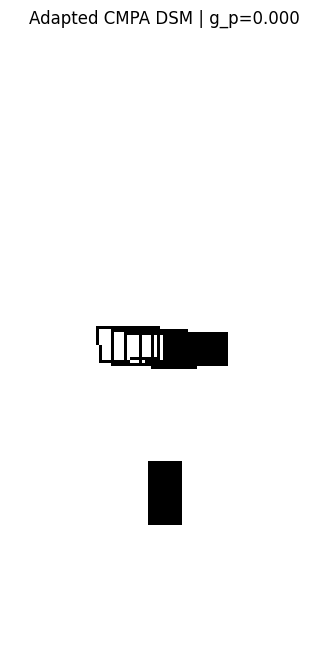

In [26]:
# ============================================================
# Visual sanity check for one DSM
# ============================================================

EXAMPLE_COMMON_INDEX = min(
    len(COMMON_KEYS) - 1,
    max(0, len(COMMON_KEYS) // 3),
)

_example_sid, _example_end = COMMON_KEYS[
    EXAMPLE_COMMON_INDEX
]

_example_prefix = scene_to_X[
    _example_sid
][:_example_end + 1]

_example_red, _example_meta = build_cmpa_red_plane(
    _example_prefix
)

_example_rgb = red_plane_to_rgb_tensor(
    _example_red
).transpose(1, 2, 0)

print("Example key:", (_example_sid, _example_end))
print("g_p:", round(_example_meta["gp"], 6))
print("Step probabilities:", np.round(_example_meta["step_probs"], 6))
print("Current filtered state [x,y,vx,vy,theta,ax]:")
print(np.round(_example_meta["current_state"], 4))
print("Future states:")
print(np.round(_example_meta["future_states"], 4))

plt.figure(figsize=(5, 8))
plt.imshow(_example_rgb)
plt.title(f"Adapted CMPA DSM | g_p={_example_meta['gp']:.3f}")
plt.axis("off")
plt.show()


# CMPA CNN

The paper's **reported topology** is preserved:

- Conv \(3\times3\) → MaxPool \(2\times2\) → ReLU;
- Conv \(3\times3\) → MaxPool \(2\times2\) → ReLU;
- Conv \(3\times3\) → ReLU;
- Dropout in the fully connected classifier.

Only the final 13-way softmax head is necessarily replaced by one binary
logit because the QCar dataset has no collision-impact-section labels.

`CMPA-BCE` and `CMPA-nnPU` use **the exact same network initialization seed
within each noise condition**.


In [27]:
# ============================================================
# Adapted CMPA CNN
# ============================================================

class AdaptedCMPACNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                3,
                CMPA_C1,
                kernel_size=3,
                padding=1,
            ),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                CMPA_C1,
                CMPA_C2,
                kernel_size=3,
                padding=1,
            ),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2,
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                CMPA_C2,
                CMPA_C3,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
        )

        # Infer flattened dimension exactly from the paper-sized DSM.
        with torch.no_grad():
            dummy = torch.zeros(
                1, 3, CMPA_H, CMPA_W
            )
            flat_dim = int(
                self.features(dummy).numel()
            )

        self.dropout = nn.Dropout(
            CMPA_DROPOUT
        )

        # Necessary task adaptation: 13 collision-mode/safe classes -> 1 binary logit.
        self.classifier = nn.Linear(
            flat_dim,
            1,
        )

    def forward(self, x):
        h = self.features(x)
        h = h.flatten(1)
        h = self.dropout(h)
        return self.classifier(h).squeeze(-1)


_cmpa_check = AdaptedCMPACNN()

print(
    "Adapted CMPA trainable parameters:",
    f"{sum(p.numel() for p in _cmpa_check.parameters() if p.requires_grad):,}"
)


Adapted CMPA trainable parameters: 103,585


# Precompute the CMPA DSM cache

DSM geometry is deterministic with respect to each clean prefix; label
corruption changes only the training target, not the input.

To avoid rebuilding Kalman predictions and \(201\times101\) maps at every
epoch, the notebook stores **only the red plane** for every common sample in
a memory-mapped `.npy` file. The full RGB DSM is reconstructed when a sample
is loaded.

Expected disk size is roughly 240 MB for ~11.8k common samples, instead of
~720 MB for full uint8 RGB maps.


In [28]:
# ============================================================
# Build / load CMPA DSM cache
# ============================================================

def build_or_load_cmpa_cache():
    expected_shape = (
        N_COMMON,
        CMPA_H,
        CMPA_W,
    )

    if CMPA_CACHE_PATH.exists():
        arr = np.load(
            CMPA_CACHE_PATH,
            mmap_mode="r",
        )

        if arr.shape == expected_shape and arr.dtype == np.uint8:
            print(
                "Using existing CMPA DSM cache:",
                CMPA_CACHE_PATH,
                arr.shape,
            )
            return arr

        print(
            "Existing cache shape/dtype mismatch; rebuilding.",
            arr.shape,
            arr.dtype,
        )

    mm = np.lib.format.open_memmap(
        CMPA_CACHE_PATH,
        mode="w+",
        dtype=np.uint8,
        shape=expected_shape,
    )

    for idx, (sid, end) in enumerate(COMMON_KEYS):
        prefix = scene_to_X[
            sid
        ][:end + 1]

        red, _ = build_cmpa_red_plane(
            prefix
        )

        mm[idx] = red

        if (
            idx == 0
            or (idx + 1) % 500 == 0
            or idx + 1 == N_COMMON
        ):
            print(
                f"CMPA DSM cache: "
                f"{idx+1:,}/{N_COMMON:,}"
            )

    mm.flush()
    del mm

    arr = np.load(
        CMPA_CACHE_PATH,
        mmap_mode="r",
    )

    print(
        "CMPA cache built:",
        CMPA_CACHE_PATH,
        arr.shape,
    )

    return arr


CMPA_RED_CACHE = build_or_load_cmpa_cache()


CMPA DSM cache: 1/11,772
CMPA DSM cache: 500/11,772
CMPA DSM cache: 1,000/11,772
CMPA DSM cache: 1,500/11,772
CMPA DSM cache: 2,000/11,772
CMPA DSM cache: 2,500/11,772
CMPA DSM cache: 3,000/11,772
CMPA DSM cache: 3,500/11,772
CMPA DSM cache: 4,000/11,772
CMPA DSM cache: 4,500/11,772
CMPA DSM cache: 5,000/11,772
CMPA DSM cache: 5,500/11,772
CMPA DSM cache: 6,000/11,772
CMPA DSM cache: 6,500/11,772
CMPA DSM cache: 7,000/11,772
CMPA DSM cache: 7,500/11,772
CMPA DSM cache: 8,000/11,772
CMPA DSM cache: 8,500/11,772
CMPA DSM cache: 9,000/11,772
CMPA DSM cache: 9,500/11,772
CMPA DSM cache: 10,000/11,772
CMPA DSM cache: 10,500/11,772
CMPA DSM cache: 11,000/11,772
CMPA DSM cache: 11,500/11,772
CMPA DSM cache: 11,772/11,772
CMPA cache built: cmpa_red_dsm_cache_uint8.npy (11772, 201, 101)


# CMPA dataset, training, and evaluation

Two CMPA variants are trained under identical inputs/splits:

\[
\text{CMPA-BCE}
\]

uses ordinary binary cross-entropy, while

\[
\text{CMPA-nnPU}
\]

replaces **only the learning objective** with the exact nnPU loss used by the
Transformer branch.

Validation always uses the unchanged clean censored label \(s_t\), matching
the supplied comparison notebook.


In [29]:
# ============================================================
# CMPA Dataset + training
# ============================================================

class CommonCMPADataset(Dataset):
    """
    CMPA DSMs in exactly the same COMMON_KEYS order as the TF dataset.
    """

    def __init__(self, noise_map=None):
        self.noise_map = noise_map

    def __len__(self):
        return N_COMMON

    def __getitem__(self, idx):
        sid, end = COMMON_KEYS[idx]

        clean_s = int(
            scene_to_s[sid][end]
        )

        train_y = (
            int(self.noise_map[(sid, end)])
            if (
                self.noise_map is not None
                and (sid, end) in self.noise_map
            )
            else clean_s
        )

        red = np.asarray(
            CMPA_RED_CACHE[idx],
            dtype=np.uint8,
        )

        x = red_plane_to_rgb_tensor(
            red
        )

        return (
            torch.from_numpy(x),
            torch.tensor(
                train_y,
                dtype=torch.float32,
            ),
            torch.tensor(
                clean_s,
                dtype=torch.float32,
            ),
        )


@torch.no_grad()
def evaluate_cmpa_clean_s(
    model,
    loader,
    threshold=0.5,
):
    model.eval()

    all_probs = []
    all_labels = []

    for x, train_y, eval_y in loader:
        x = x.to(device)

        logits = model(x)

        probs = torch.sigmoid(
            logits
        ).cpu().numpy()

        all_probs.append(
            probs
        )

        all_labels.append(
            eval_y.numpy()
        )

    y_true = np.concatenate(
        all_labels
    ).astype(int)

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = (
        y_prob >= threshold
    ).astype(int)

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
    }


def train_cmpa_prefix_split(
    noise_map,
    loss_mode,
    prior=POS_PRIOR,
    seed=SEED,
):
    set_seed(seed)

    full_ds = CommonCMPADataset(
        noise_map=noise_map
    )

    train_ds = Subset(
        full_ds,
        TRAIN_IDX.tolist(),
    )

    val_ds = Subset(
        full_ds,
        VAL_IDX.tolist(),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=CMPA_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=128,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model = AdaptedCMPACNN().to(
        device
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CMPA_LR,
        weight_decay=CMPA_WEIGHT_DECAY,
    )

    early_stopper = EarlyStopping(
        patience=CMPA_PATIENCE,
        min_delta=CMPA_MIN_DELTA,
        mode="max",
    )

    best_epoch = None

    for epoch in range(
        1,
        CMPA_MAX_EPOCHS + 1,
    ):
        model.train()

        for x, train_y, eval_y in train_loader:
            x = x.to(
                device,
                non_blocking=True,
            )

            train_y = train_y.to(
                device,
                non_blocking=True,
            )

            logits = model(x)

            if loss_mode == "bce":
                loss = (
                    F.binary_cross_entropy_with_logits(
                        logits,
                        train_y,
                    )
                )

            elif loss_mode == "nnpu":
                loss = nnpu_loss(
                    logits,
                    train_y,
                    prior=prior,
                    gamma=1.0,
                    beta=0.0,
                )

            else:
                raise ValueError(
                    loss_mode
                )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_metrics = evaluate_cmpa_clean_s(
            model,
            val_loader,
        )

        stop = early_stopper.step(
            val_metrics["f1"],
            model,
        )

        if (
            val_metrics["f1"]
            == early_stopper.best
        ):
            best_epoch = epoch

        if stop:
            break

    early_stopper.restore_best_weights(
        model
    )

    metrics = evaluate_cmpa_clean_s(
        model,
        val_loader,
    )

    metrics["best_epoch"] = best_epoch

    return metrics


# Run the complete clean + noise comparison

For every corruption condition:

1. build one shared training-noise map;
2. train **TF-nnPU**;
3. train **CMPA-BCE**;
4. train **CMPA-nnPU**.

The two CMPA runs use the same model initialization seed within a condition,
so their difference is attributable to the learning objective rather than a
different random initialization.


In [30]:
# ============================================================
# Full TF-nnPU vs CMPA experiment
# ============================================================

RESULTS_CSV = Path(
    "prefix_level_tf_vs_cmpa_results.csv"
)


def run_full_comparison():
    rows = []

    for condition_idx, (
        noise_mode,
        noise_rate,
    ) in enumerate(NOISE_CONDITIONS):

        noise_map, noise_stats = (
            make_training_noise_map(
                noise_mode,
                noise_rate,
                seed=SEED + 1000*condition_idx,
            )
        )

        print("\n" + "=" * 78)
        print(
            f"{noise_mode} | "
            f"rate={noise_rate:.0%} | "
            f"flipped={noise_stats['flipped_total']}/"
            f"{noise_stats['n_train']} | "
            f"P->U={noise_stats['p_to_u']} | "
            f"U->P={noise_stats['u_to_p']}"
        )
        print("=" * 78)

        # ----------------------------
        # TF-nnPU — unchanged
        # ----------------------------
        tf = train_tf_nnpu_prefix_split(
            noise_map,
            prior=POS_PRIOR,
            seed=SEED + condition_idx,
        )

        rows.append({
            "method": "TF-nnPU",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            **tf,
            **noise_stats,
        })

        print(
            "TF-nnPU:",
            {
                k: round(tf[k], 4)
                for k in [
                    "precision",
                    "recall",
                    "f1",
                ]
            },
        )

        # Same initialization for CMPA-BCE and CMPA-nnPU.
        cmpa_seed = (
            SEED
            + 5000
            + condition_idx
        )

        # ----------------------------
        # CMPA-BCE
        # ----------------------------
        cmpa_bce = train_cmpa_prefix_split(
            noise_map,
            loss_mode="bce",
            prior=POS_PRIOR,
            seed=cmpa_seed,
        )

        rows.append({
            "method": "CMPA-BCE",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            **cmpa_bce,
            **noise_stats,
        })

        print(
            "CMPA-BCE:",
            {
                k: round(cmpa_bce[k], 4)
                for k in [
                    "precision",
                    "recall",
                    "f1",
                ]
            },
        )

        # ----------------------------
        # CMPA-nnPU
        # ----------------------------
        cmpa_nnpu = train_cmpa_prefix_split(
            noise_map,
            loss_mode="nnpu",
            prior=POS_PRIOR,
            seed=cmpa_seed,
        )

        rows.append({
            "method": "CMPA-nnPU",
            "noise_mode": noise_mode,
            "noise_rate": noise_rate,
            **cmpa_nnpu,
            **noise_stats,
        })

        print(
            "CMPA-nnPU:",
            {
                k: round(cmpa_nnpu[k], 4)
                for k in [
                    "precision",
                    "recall",
                    "f1",
                ]
            },
        )

        pd.DataFrame(
            rows
        ).to_csv(
            RESULTS_CSV,
            index=False,
        )

    return pd.DataFrame(
        rows
    )


RUN_FULL_EXPERIMENT = True

if RUN_FULL_EXPERIMENT:
    results = run_full_comparison()



none | rate=0% | flipped=0/9417 | P->U=0 | U->P=0


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9562, 'recall': 0.9103, 'f1': 0.9327}
CMPA-BCE: {'precision': 0.9038, 'recall': 0.9183, 'f1': 0.911}
CMPA-nnPU: {'precision': 0.8758, 'recall': 0.9038, 'f1': 0.8896}

symmetric | rate=5% | flipped=471/9417 | P->U=130 | U->P=341


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9411, 'recall': 0.8702, 'f1': 0.9042}
CMPA-BCE: {'precision': 0.9051, 'recall': 0.8862, 'f1': 0.8955}
CMPA-nnPU: {'precision': 0.9054, 'recall': 0.8894, 'f1': 0.8973}

symmetric | rate=10% | flipped=942/9417 | P->U=237 | U->P=705


...

TF-nnPU: {'precision': 0.9048, 'recall': 0.883, 'f1': 0.8938}
CMPA-BCE: {'precision': 0.8961, 'recall': 0.9119, 'f1': 0.9039}
CMPA-nnPU: {'precision': 0.8682, 'recall': 0.9183, 'f1': 0.8925}

p_to_u | rate=15% | flipped=393/9417 | P->U=393 | U->P=0


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9344, 'recall': 0.867, 'f1': 0.8994}
CMPA-BCE: {'precision': 0.9003, 'recall': 0.8542, 'f1': 0.8766}
CMPA-nnPU: {'precision': 0.9124, 'recall': 0.8349, 'f1': 0.872}

p_to_u | rate=20% | flipped=523/9417 | P->U=523 | U->P=0


C:\Users\l_daryel\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TF-nnPU: {'precision': 0.9354, 'recall': 0.8349, 'f1': 0.8823}
CMPA-BCE: {'precision': 0.9167, 'recall': 0.8638, 'f1': 0.8894}
CMPA-nnPU: {'precision': 0.8988, 'recall': 0.8397, 'f1': 0.8683}


In [31]:
# Reload after notebook restart if necessary.

if "results" not in globals():
    if RESULTS_CSV.exists():
        results = pd.read_csv(
            RESULTS_CSV
        )
    else:
        raise FileNotFoundError(
            RESULTS_CSV
        )

display(results.head())


,method,noise_mode,noise_rate,accuracy,precision,recall,f1,best_epoch,n_train,clean_positive,final_positive,flipped_total,realized_flip_rate,p_to_u,u_to_p
0,TF-nnPU,none,0.00,0.965180,0.956229,0.910256,0.932677,44,9417,2617,2617,0,0.000000,0,0
1,CMPA-BCE,none,0.00,0.952442,0.903785,0.918269,0.910970,17,9417,2617,2617,0,0.000000,0,0
2,CMPA-nnPU,none,0.00,0.940552,0.875776,0.903846,0.889590,11,9417,2617,2617,0,0.000000,0,0
3,TF-nnPU,symmetric,0.05,0.951168,0.941075,0.870192,0.904246,15,9417,2617,2828,471,0.050016,130,341
4,CMPA-BCE,symmetric,0.05,0.945223,0.905074,0.886218,0.895547,7,9417,2617,2828,471,0.050016,130,341


# Final clean comparison table


In [32]:
clean = results[
    (results["noise_mode"] == "none")
    & (results["noise_rate"] == 0.0)
].copy()

clean_table = (
    clean[
        [
            "method",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "best_epoch",
        ]
    ]
    .rename(
        columns={
            "method": "Method",
            "accuracy": "Accuracy",
            "precision": "Precision",
            "recall": "Recall",
            "f1": "F1",
            "best_epoch": "Best epoch",
        }
    )
    .reset_index(drop=True)
)

clean_table.to_csv(
    "prefix_level_tf_vs_cmpa_clean_table.csv",
    index=False,
)

display(clean_table)


,Method,Accuracy,Precision,Recall,F1,Best epoch
0,TF-nnPU,0.965180,0.956229,0.910256,0.932677,44
1,CMPA-BCE,0.952442,0.903785,0.918269,0.910970,17
2,CMPA-nnPU,0.940552,0.875776,0.903846,0.889590,11


# Final F1 table under symmetric and asymmetric label corruption


In [33]:
def condition_name(row):
    if row["noise_mode"] == "none":
        return "Clean"

    if row["noise_mode"] == "symmetric":
        return (
            f"Symmetric "
            f"{int(round(100*row['noise_rate']))}%"
        )

    if row["noise_mode"] == "p_to_u":
        return (
            f"P→U "
            f"{int(round(100*row['noise_rate']))}%"
        )

    return str(row["noise_mode"])


view = results.copy()

view["Condition"] = view.apply(
    condition_name,
    axis=1,
)

noise_f1_table = (
    view.pivot(
        index="Condition",
        columns="method",
        values="f1",
    )
    .reset_index()
)

order = [
    "Clean",
    "Symmetric 5%",
    "Symmetric 10%",
    "Symmetric 15%",
    "Symmetric 20%",
    "P→U 5%",
    "P→U 10%",
    "P→U 15%",
    "P→U 20%",
]

noise_f1_table["_order"] = (
    noise_f1_table["Condition"]
    .map(
        {
            name: i
            for i, name in enumerate(order)
        }
    )
)

noise_f1_table = (
    noise_f1_table
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)

noise_f1_table.to_csv(
    "prefix_level_tf_vs_cmpa_noise_f1_table.csv",
    index=False,
)

display(noise_f1_table)


method,Condition,CMPA-BCE,CMPA-nnPU,TF-nnPU
0,Clean,0.910970,0.889590,0.932677
1,Symmetric 5%,0.895547,0.897332,0.904246
2,Symmetric 10%,0.894569,0.875000,0.894309
3,Symmetric 15%,0.883907,0.760331,0.843636
4,Symmetric 20%,0.874396,0.780884,0.849462
5,P→U 5%,0.904348,0.888889,0.904641
6,P→U 10%,0.903892,0.892523,0.893755
7,P→U 15%,0.876645,0.871967,0.899418
8,P→U 20%,0.889439,0.868268,0.882303


# F1 degradation from each model's clean score


In [34]:
clean_f1 = (
    clean
    .set_index("method")["f1"]
    .to_dict()
)

degradation = results.copy()

degradation["delta_f1_from_clean"] = (
    degradation.apply(
        lambda row:
        row["f1"]
        - clean_f1[row["method"]],
        axis=1,
    )
)

degradation = degradation[
    degradation["noise_mode"] != "none"
].copy()

degradation.to_csv(
    "prefix_level_tf_vs_cmpa_f1_degradation.csv",
    index=False,
)

display(
    degradation[
        [
            "method",
            "noise_mode",
            "noise_rate",
            "f1",
            "delta_f1_from_clean",
        ]
    ]
)


,method,noise_mode,noise_rate,f1,delta_f1_from_clean
3,TF-nnPU,symmetric,0.05,0.904246,-0.028430
4,CMPA-BCE,symmetric,0.05,0.895547,-0.015423
5,CMPA-nnPU,symmetric,0.05,0.897332,0.007742
6,TF-nnPU,symmetric,0.10,0.894309,-0.038368
7,CMPA-BCE,symmetric,0.10,0.894569,-0.016401
8,CMPA-nnPU,symmetric,0.10,0.875000,-0.014590
9,TF-nnPU,symmetric,0.15,0.843636,-0.089040
10,CMPA-BCE,symmetric,0.15,0.883907,-0.027063
11,CMPA-nnPU,symmetric,0.15,0.760331,-0.129259
12,TF-nnPU,symmetric,0.20,0.849462,-0.083214


# Robustness plots


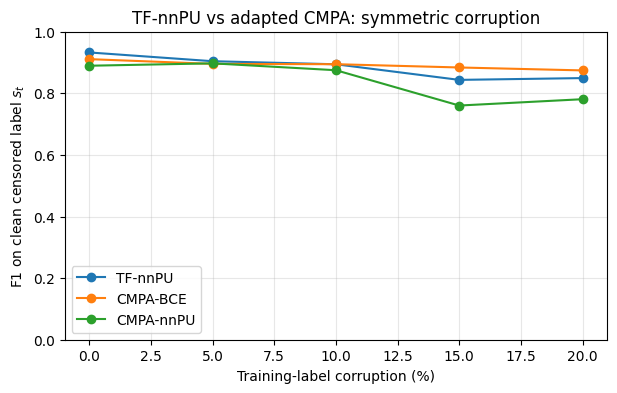

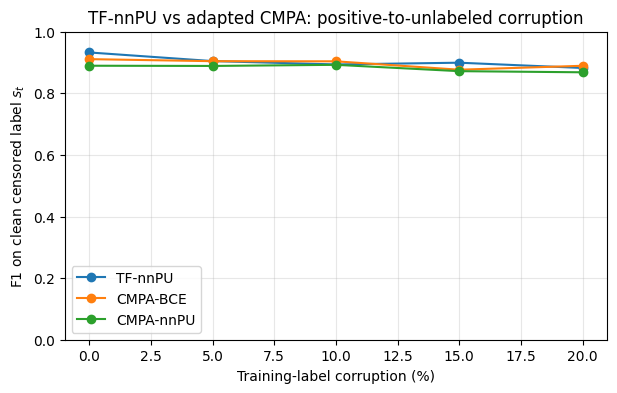

In [35]:
def plot_noise(
    results,
    mode,
    title,
):
    plt.figure(
        figsize=(7, 4)
    )

    clean_rows = results[
        (results["noise_mode"] == "none")
        & (results["noise_rate"] == 0.0)
    ]

    noisy_rows = results[
        results["noise_mode"] == mode
    ]

    for method in [
        "TF-nnPU",
        "CMPA-BCE",
        "CMPA-nnPU",
    ]:
        xs = [0]

        ys = [
            float(
                clean_rows[
                    clean_rows["method"]
                    == method
                ]["f1"].iloc[0]
            )
        ]

        for rate in [
            0.05,
            0.10,
            0.15,
            0.20,
        ]:
            row = noisy_rows[
                (noisy_rows["method"] == method)
                & (
                    noisy_rows["noise_rate"]
                    == rate
                )
            ]

            xs.append(
                int(round(rate * 100))
            )

            ys.append(
                float(row["f1"].iloc[0])
            )

        plt.plot(
            xs,
            ys,
            marker="o",
            label=method,
        )

    plt.xlabel(
        "Training-label corruption (%)"
    )

    plt.ylabel(
        "F1 on clean censored label $s_t$"
    )

    plt.ylim(0, 1)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


plot_noise(
    results,
    "symmetric",
    "TF-nnPU vs adapted CMPA: symmetric corruption",
)

plot_noise(
    results,
    "p_to_u",
    "TF-nnPU vs adapted CMPA: positive-to-unlabeled corruption",
)


# Automatic result summary


In [36]:
print("=" * 76)
print("FULL TF-nnPU vs ADAPTED CMPA COMPARISON")
print("=" * 76)

for _, row in clean_table.iterrows():
    print(
        f"{row['Method']}: "
        f"P={row['Precision']:.4f}, "
        f"R={row['Recall']:.4f}, "
        f"F1={row['F1']:.4f}"
    )

best_clean = clean.loc[
    clean["f1"].idxmax()
]

print()
print(
    "Best clean:",
    best_clean["method"],
    f"F1={best_clean['f1']:.4f}",
)

for mode in [
    "symmetric",
    "p_to_u",
]:
    rows20 = results[
        (results["noise_mode"] == mode)
        & (results["noise_rate"] == 0.20)
    ]

    best20 = rows20.loc[
        rows20["f1"].idxmax()
    ]

    print(
        f"Best at 20% {mode}:",
        best20["method"],
        f"F1={best20['f1']:.4f}",
    )

# Most important transfer-of-supervision comparison.
cmpa_clean = clean.set_index("method")

if (
    "CMPA-BCE" in cmpa_clean.index
    and "CMPA-nnPU" in cmpa_clean.index
):
    print()
    print(
        "CMPA clean ΔF1 (nnPU - BCE):",
        f"{cmpa_clean.loc['CMPA-nnPU','f1'] - cmpa_clean.loc['CMPA-BCE','f1']:+.4f}",
    )

for mode in ["symmetric", "p_to_u"]:
    for rate in [0.10, 0.15, 0.20]:
        sub = results[
            (results["noise_mode"] == mode)
            & (results["noise_rate"] == rate)
        ].set_index("method")

        if (
            "CMPA-BCE" in sub.index
            and "CMPA-nnPU" in sub.index
        ):
            print(
                f"CMPA ΔF1 nnPU-BCE at {int(rate*100)}% {mode}:",
                f"{sub.loc['CMPA-nnPU','f1'] - sub.loc['CMPA-BCE','f1']:+.4f}",
            )

print()
print(
    "Validation-scene overlap:",
    f"{100*len(overlap_scenes)/max(1,len(val_scenes)):.2f}%"
)


FULL TF-nnPU vs ADAPTED CMPA COMPARISON
TF-nnPU: P=0.9562, R=0.9103, F1=0.9327
CMPA-BCE: P=0.9038, R=0.9183, F1=0.9110
CMPA-nnPU: P=0.8758, R=0.9038, F1=0.8896

Best clean: TF-nnPU F1=0.9327
Best at 20% symmetric: CMPA-BCE F1=0.8744
Best at 20% p_to_u: CMPA-BCE F1=0.8894

CMPA clean ΔF1 (nnPU - BCE): -0.0214
CMPA ΔF1 nnPU-BCE at 10% symmetric: -0.0196
CMPA ΔF1 nnPU-BCE at 15% symmetric: -0.1236
CMPA ΔF1 nnPU-BCE at 20% symmetric: -0.0935
CMPA ΔF1 nnPU-BCE at 10% p_to_u: -0.0114
CMPA ΔF1 nnPU-BCE at 15% p_to_u: -0.0047
CMPA ΔF1 nnPU-BCE at 20% p_to_u: -0.0212

Validation-scene overlap: 100.00%


# Interpretation for the reviewer response

The strongest result is **not necessarily that TF-nnPU must beat CMPA in
clean F1**.

The reviewer-facing question is:

\[
\boxed{
\text{Does nnPU improve robustness when transferred to an independent
published collision-prediction architecture?}
}
\]

The key comparisons are therefore:

\[
F1_{\text{CMPA-nnPU}}
-
F1_{\text{CMPA-BCE}}
\]

under clean, symmetric-noise, and \(P\rightarrow U\) asymmetric-noise
conditions.

A strong outcome would be:

- CMPA-BCE is competitive in the clean setting;
- CMPA-BCE degrades rapidly as supervision is corrupted;
- CMPA-nnPU retains substantially higher F1 under the same corrupted
  training samples;
- TF-nnPU and CMPA-nnPU show similar robustness trends.

That would support the paper's central claim that the robustness benefit
comes from **PU supervision rather than a Transformer-specific architectural
advantage**.

## Wording discipline

In the manuscript/response letter, call this:

> **an adapted binary implementation of the CMPA framework of Lee et al.**

Do **not** call it an exact reproduction because the original study uses:

- 13 collision-mode/safe classes;
- explicit lane geometry;
- its own sensor-fusion uncertainty model;
- an active-learning/data-curation procedure.

This notebook preserves the core CMPA abstraction, probabilistic
trajectory/threat representation, DSM dimensions and CNN topology as far as
the available QCar data and the published methodological detail permit.
